This is a tidied up version of the script used for the first verison of the paper

In [1]:
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity

# ── Paths ──────────────────────────────────────────────────────────────────
TOD_PATH      = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod"
GREX_PATH     = "/Users/madalina/Documents/M2TAL/stage/grex/grex2"
TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/SUD_French-Rhapsodie/prosody_no_punct.conllu"
# TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/pSUD_Naija-NSC"
PATTERNS_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes_prosody.txt"

GREW_PATTERN      = "pattern{X[upos<>PUNCT]}"

# ── Bring third-party packages onto the path ───────────────────────────────
for p in (TOD_PATH, GREX_PATH):
    if p not in sys.path:
        sys.path.insert(1, p)

import pyximport
pyximport.install()

import grewpy
from grewpy import Corpus, CorpusDraft, Request

import tod.corpus  # noqa: F401  (registers handlers; keep import)

import grex.data           # noqa: F401
import grex.utils
import grex.features       # noqa: F401
import grex.data_prosody

grewpy.set_config("sud")

connected to port: 60844


In [2]:
# ── Drop entirely: redundant, unreliable, or too fine-grained ─────────────
FEATURES_TO_DROP = {
    'MeanF0',           # use SemitonesFromUtteranceMean instead (speaker-normalised)
    'MeanF0Step',       # threshold artefact, not a prosodic observation
    'AvgAmplitude',     # recording-condition-dependent
    'MaxAmplitude',     # same
    'SylForm',          # phonetic transcription, too fine-grained
    'AlignBegin',       # timing offset, not linguistic
    'AlignEnd',         # timing offset, not linguistic
    'pauseID',          # identifier, not a feature
    # Before*/Next* equivalents of dropped features:
    'BeforeMeanF0', 'BeforeMeanF0Step', 'BeforeAvgAmplitude',
    'NextMeanF0',   'NextMeanF0Step',   'NextAvgAmplitude',
    'Semiton', 'Overlap', 'Loc', 'Glo', 'Backchannel',
    "AvgAmplitudeNormalized", "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized"
}

# ── Bin into 3 quantile-based categories ──────────────────────────────────
# Note: Duration appears in TWO units in the data:
#   - syllable subnodes: integer ms     (e.g. 289, 167)
#   - pause nodes:       float seconds  (e.g. 0.2695, 0.3328)
# We normalise to ms before binning — see `_normalise_duration` below.
FEATURES_TO_BIN = {
    'SemitonesFromUtteranceMean',
    'Duration',
    'BeforeSemitonesFromUtterance',
    'NextSemitonesFromUtterance',
    'BeforeDuration',
    'NextDuration',
    'BeforeSemiton',
    'NextSemiton',
    'NextSemitonsFromUtterance',
    'NextBreakLength',
    'AvgAmplitudeGlobalZscore', # naija
    # naija
    "DurationGlobalZscore" # naija
}

BIN_LABELS = {
    'SemitonesFromUtteranceMean':   ['F0_low',       'F0_mid',       'F0_high'],
    'Duration':                     ['Dur_short',    'Dur_mid',      'Dur_long'],
    'BeforeSemitonesFromUtterance': ['BeforeF0_low', 'BeforeF0_mid', 'BeforeF0_high'],
    'NextSemitonesFromUtterance':   ['NextF0_low',   'NextF0_mid',   'NextF0_high'],
    'NextBreakLength':              ['NextBreak_short', 'NextBreak_mid', 'NextBreak_long'],
    
}


In [3]:
# ── SLAM3 contour decomposition ───────────────────────────────────────────
# The *Tone features (FootTone, GroupTone, PackageTone, Period_tone) encode
# pitch contours compositionally:
#
#     [start_pitch][end_pitch]            -- no salient peak (2 chars)
#     [start_pitch][end_pitch][peak][tier] -- with salient peak (4 chars)
#
# pitch ∈ {L, l, m, h, H}  (5 ordinal levels: very low → very high)
# tier  ∈ {1, 2, 3}        (which syllabic tier carries the peak)
# Plus the special atomic value 'Pause'.
#
# Treating these as opaque strings gives ~300 sparse one-hot columns per
# *Tone feature. Decomposing into {start, end, peak, tier, has_peak,
# direction, magnitude} yields ~5 dense sub-features per token instead.

SLAM_TONE_FEATURES = {'FootTone', 'GroupTone', 'PackageTone', 'Period_tone', 'Period', 'PeriodTone'}

# Ordinal mapping used to derive direction & magnitude.
_PITCH_LEVELS = {'L': 1, 'l': 2, 'm': 3, 'h': 4, 'H': 5}
_TIERS = {'1', '2', '3'}


def _parse_slam(label):
    """Parse a SLAM3 contour string into its components.

    Returns a dict {pause, start, end, peak, tier} or None if the label
    doesn't match the SLAM3 grammar (silently skipped downstream).
    """
    if label == 'Pause':
        return {'pause': True, 'start': None, 'end': None,
                'peak': None, 'tier': None}

    if (len(label) == 2
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': None, 'tier': None}

    if (len(label) == 4
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS
            and label[2] in _PITCH_LEVELS and label[3] in _TIERS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': label[2], 'tier': label[3]}

    return None


def _slam_subfeatures(prefix, label):
    """Yield 'sub-feature=value' strings derived from a SLAM3 contour label.

    `prefix` is the path up to and including the *Tone name,
    e.g. 'node:X:child:GroupTone'. Sub-features become
    'node:X:child:GroupTone:start=H', 'node:X:child:GroupTone:direction=rise', …
    """
    parsed = _parse_slam(label)
    if parsed is None:
        return

    if parsed['pause']:
        yield f"{prefix}:pause=True"
        return

    s, e = parsed['start'], parsed['end']
    yield f"{prefix}:start={s}"
    yield f"{prefix}:end={e}"

    # Direction & magnitude on the ordinal pitch scale.
    delta = _PITCH_LEVELS[e] - _PITCH_LEVELS[s]
    if delta > 0:
        direction = 'rise'
    elif delta < 0:
        direction = 'fall'
    else:
        direction = 'flat'
    yield f"{prefix}:direction={direction}"
    yield f"{prefix}:magnitude={abs(delta)}"

    if parsed['peak'] is not None:
        yield f"{prefix}:has_peak=True"
        yield f"{prefix}:peak={parsed['peak']}"
        yield f"{prefix}:tier={parsed['tier']}"
    else:
        yield f"{prefix}:has_peak=False"

In [4]:
def _normalise_duration(value_str):
    """Convert a Duration string to milliseconds regardless of source node type.

    Syllable subnodes store ms (e.g. '289'); pause nodes store seconds
    (e.g. '0.2695'). Heuristic: values < 10 are seconds. A literal 0.0 means
    'missing' (e.g. overlap nodes) → returns None.
    """
    try:
        v = float(value_str)
    except (ValueError, TypeError):
        return None
    if v == 0.0:
        return None
    return v * 1000 if v < 10 else v


def _is_sentinel(value_str):
    """True for the '0.0' sentinel that overlap / missing pause nodes carry.

    Without this guard, those zeros would be binned as F0_low rather than
    silently dropped.
    """
    try:
        return float(value_str) == 0.0
    except (ValueError, TypeError):
        return False


def _feature_name(key):
    """Bare feature name from a path-like key, e.g. ('node','X','child','Duration') → 'Duration'."""
    return key[-1]


In [5]:
def collect_continuous_values(all_data_items):
    """Walk every (lex_unit, match, features) triple and collect raw float
    values for each feature in FEATURES_TO_BIN.

    Returns: {feature_name: [float, ...]}
    """
    collector = {f: [] for f in FEATURES_TO_BIN}

    for _, _, features in all_data_items:
        for key, value in features.items():
            fname = _feature_name(key)
            if fname not in FEATURES_TO_BIN:
                continue
            # `value` is a string for own/parent/prev/next, or a set of strings
            # for child (a node can have multiple syllables).
            values = value if isinstance(value, set) else {value}
            for v in values:
                if fname == 'Duration':
                    norm = _normalise_duration(v)
                    if norm is not None:
                        collector['Duration'].append(norm)
                elif not _is_sentinel(v):
                    try:
                        collector[fname].append(float(v))
                    except (ValueError, TypeError):
                        pass
    return collector


def compute_thresholds(collector, n_bins=3):
    """Quantile boundaries (interior only) per feature.

    Returns: {feature_name: [boundary_1, boundary_2, ...]}
    """
    thresholds = {}
    for fname, values in collector.items():
        if not values:
            continue
        arr = np.array(values)
        quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
        thresholds[fname] = np.quantile(arr, quantiles).tolist()
    return thresholds


In [6]:
def _bin_value(fname, value_str, thresholds):
    """Continuous string → bin label. Returns None for sentinels / unknowns."""
    if fname not in thresholds or _is_sentinel(value_str):
        return None

    if fname == 'Duration':
        v = _normalise_duration(value_str)
    else:
        try:
            v = float(value_str)
        except (ValueError, TypeError):
            return None

    if v is None:
        return None

    bounds = thresholds[fname]
    labels = BIN_LABELS.get(fname, [f'{fname}_Q1', f'{fname}_Q2', f'{fname}_Q3'])
    for i, b in enumerate(bounds):
        if v <= b:
            return labels[i]
    return labels[-1]


def format_features(features, thresholds):
    """Turn a feature dict into a list of 'k1:k2:...:kn=value' strings.

    Continuous features are binned; dropped features are skipped.
    """
    result = []
    for key, value in features.items():
        fname = _feature_name(key)
        prefix = ':'.join(key)

        if fname in FEATURES_TO_DROP:
            continue

        if fname in FEATURES_TO_BIN:
            values = value if isinstance(value, set) else {value}
            for v in values:
                label = _bin_value(fname, v, thresholds)
                if label is not None:
                    result.append(f"{prefix}={label}")
            continue
        
        # if fname == 'Period':
        #     # Strip *, -, and prefix/suffix markers to collapse 16 values down to 4.
        #     for v in values:
        #         cleaned = v.strip('*-')
        #         result.append(f"{prefix}={cleaned}")
        #     # If you want to preserve the pause-adjacency information as its own
        #     # feature, add a boolean:
        #     if any('*' in v or '-' in v for v in values):
        #         result.append(f"{prefix}_pause_adjacent=True")
        #     continue
        
        # SLAM3 contour features: decompose into structural sub-features.
        if fname in SLAM_TONE_FEATURES:
            values = value if isinstance(value, set) else {value}
            for v in values:
                result.extend(_slam_subfeatures(prefix, v))
            continue


        # Categorical: keep as-is.
        if isinstance(value, set):
            for v in value:
                result.append(f"{prefix}={v}")
        else:
            result.append(f"{prefix}={value}")

    return result


def _filter_features(features, excluded_patterns=None, included_patterns=None):
    """Regex-based include/exclude filter over a list of feature strings."""
    import re
    out = []
    for feature in features:
        if excluded_patterns and any(re.search(p, feature) for p in excluded_patterns):
            continue
        if included_patterns and not any(re.search(p, feature) for p in included_patterns):
            continue
        out.append(feature)
    return out


In [7]:
corpus = grewpy.Corpus(TREEBANK_PATH)
draft  = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(
    grewpy.Request(GREW_PATTERN)
        .without("X[InIdiom=Yes]")
        .without("X[Idiom=Yes]")
        .without("X[InTitle=Yes]")
        .without("X[Title=Yes]")
        .without("X[Scrap=Yes]")
        .without("X[Foreign]")
        .without("X[Lang]")
        .without("X-[fixed]->Y")
        .without("Y-[flat:name]->X")
        .without("Y-[goeswith]->X"),
    clustering_keys=["X.form"],
)

# Drop lemmas with fewer than 10 occurrences.
# matches = {k: v for k, v in all_matches.items() if len(v) > 10}
matches=all_matches

# sent_id → {node_id: features}
sent_id_to_sentence = {
    draft[i].meta["sent_id"]: draft[i].features for i in range(len(draft))  # type: ignore
}


In [8]:
# Re-key by (lemma, POS). Use ExtPos when present (e.g. '%' has upos=SYM but
# ExtPos=NOUN, and we want NOUN). Otherwise fall back to upos.
match_upos = {}
for lemma, occurrences in matches.items():
    for m in occurrences:
        sent_id = m["sent_id"]
        node_id = str(m["matching"]["nodes"]["X"])
        sentence_features = sent_id_to_sentence.get(sent_id)
        if sentence_features is None or node_id not in sentence_features:
            continue
        token_features = sentence_features[node_id]
        if "ExtPos" in token_features:
            pos = token_features["ExtPos"]
        elif "upos" in token_features:
            pos = token_features["upos"]
        else:
            print(f"WARNING: lemma '{lemma}' in '{sent_id}' has no upos.")
            continue
        match_upos.setdefault((lemma, pos), []).append(m)

# Filter again post-split: a lemma may have passed at the lemma level but
# split into rare (lemma, POS) pairs.
# match_upos = {k: v for k, v in match_upos.items() if len(v) > 10}



In [9]:
with open(PATTERNS_FILE) as f:
    config = yaml.load(f, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(
    config["features"], templates=templates,
)

all_data_items = []
for lex_unit, mts in match_upos.items():
    for match in mts:
        feats = grex.data_prosody.extract_features(draft, match, feature_predicate)
        all_data_items.append((lex_unit, match, feats))

print(f"Total (lex_unit, match, features) triples: {len(all_data_items)}")

Total (lex_unit, match, features) triples: 33175


In [10]:
# Compute corpus-wide quantile thresholds, then format every match's features
# (binning the continuous ones, dropping the unwanted ones).
collector  = collect_continuous_values(all_data_items)
thresholds = compute_thresholds(collector, n_bins=3)

print("Computed thresholds:")
for fname, bounds in thresholds.items():
    labels = BIN_LABELS.get(fname, ['Q1', 'Q2', 'Q3'])
    print(
        f"  {fname}: <{bounds[0]:.3f} → {labels[0]} | "
        f"<{bounds[1]:.3f} → {labels[1]} | ≥{bounds[1]:.3f} → {labels[2]}"
    )

# Drop 'own' features (the focused node's own attributes — they trivially
# determine its category and would dominate similarity).
EXCLUDED_FEATURE_PATTERNS = [# Own features that would trivially recover POS or aren't prosodic
    'upos', 'lemma', 'form',
    'rel_shallow', 'deprel',
    'Case', 'Definite', 'Gender', 'Mood',
    'Number', 'NumType', 'Person', 'Polarity',
    'Poss', 'PronType', 'Reflex', 'Tense',
    'VerbForm', 'Voice',
    'Number[lex]', 'Person[lex]',
    'Gender[ctxt]', 'Number[ctxt]',
    'ExtPos', 'Foreign', 'Lang', 'Emph',
    'HasSpokenGender', 'HasSpokenNumber',
    'AlignBegin', 'AlignEnd', 'SylForm', 'SpaceAfter',
    # Unmeasurable slope
    'Slope=X',
    # Fused: rare and per-syllable, drops signal-to-noise
    'Fused=Yes',
    # Redundant local slope (keep the Glo scope)
    ':Slope=',
    # Morphological features of dependents — clutter the syntactic space
    'own:Filler=', "Token2=", "rel_deep=", "__MISC__Rel=", "TypePara=", "TypeInherited=", "Truncated=", "Subject=", "Token3", "Token4", "ProminenceFinal=0", "ProminenceInitial=0", "UtteranceMeanF0=0.0",
    "IU", "nucleus", "Layer", "Filler=", "Shared",     
    'ExtPos', "Loc=", "direction=flat", "has_peak=False", 
    # "FootTone:pause", "GroupTone:pause", "PackageTone:pause", "Period_tone:pause", "ProminenceFinal=Pause", "ProminenceInitial=Pause",

                             "AvgAmplitudeLocalZscore", "DurationLocalZscore", "MaxAmplitudeLocalZscore", "DurationNormalized", "MaxAmplitudeGlobalZscore", 
                             "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized", "MaxAmplitudeNormalized", "Coda"
                             ]

data = {k: [] for k in match_upos}
for lex_unit, _, features in all_data_items:
    formatted = _filter_features(
        format_features(features, thresholds),
        excluded_patterns=EXCLUDED_FEATURE_PATTERNS,
    )
    data[lex_unit].append(formatted)


Computed thresholds:
  SemitonesFromUtteranceMean: <-1.278 → F0_low | <0.529 → F0_mid | ≥0.529 → F0_high
  Duration: <133.000 → Dur_short | <199.000 → Dur_mid | ≥199.000 → Dur_long
  NextBreakLength: <0.283 → NextBreak_short | <0.528 → NextBreak_mid | ≥0.528 → NextBreak_long


In [11]:
# Build index lookups. These are used everywhere downstream.
unique_lemma    = sorted(set(data))
unique_features = sorted({feat for lists in data.values() for fs in lists for feat in fs})

idx2feature = {i: feat for i, feat in enumerate(unique_features)}
feature2idx = {feat: i for i, feat in idx2feature.items()}
idx2lexunit = {i: feat for i, feat in enumerate(unique_lemma)}
lexunit2idx = {feat: i for i, feat in idx2lexunit.items()}

print(f"Lexical units: {len(idx2lexunit)} | features: {len(idx2feature)}")


Lexical units: 4880 | features: 8487


In [12]:
co_occurrence_matrix = np.zeros((len(idx2lexunit), len(idx2feature)))
for lex_unit, feature_lists in data.items():
    for feature_list in feature_lists:
        for feature in feature_list:
            co_occurrence_matrix[lexunit2idx[lex_unit], feature2idx[feature]] += 1

# Occurrence count per unit, aligned to row order.
n_occ = np.array([len(data[idx2lexunit[i]]) for i in range(len(idx2lexunit))],
                 dtype=float)

occurrence_matrix = np.divide(
    co_occurrence_matrix,
    n_occ[:, np.newaxis],
    out=np.zeros_like(co_occurrence_matrix),
    where=n_occ[:, np.newaxis] != 0,
)

feature_matrix = occurrence_matrix


In [13]:
# ── Column-frequency filter ───────────────────────────────────────────────
# Drop feature columns that are non-zero on fewer than MIN_LEXUNITS lexical
# units. Such columns contribute mostly noise to cosine similarity (they look
# like spurious axes of variation between the few units that happen to use
# them) and bloat the matrix.
#
# Cosine similarity is scale-invariant, so we don't renormalise rows after
# dropping columns — within-row ratios are preserved.
MIN_LEXUNITS = 10

col_nonzero_per_lexunit = (co_occurrence_matrix > 0).sum(axis=0)
keep_cols = col_nonzero_per_lexunit >= MIN_LEXUNITS

n_before = feature_matrix.shape[1]
co_occurrence_matrix = co_occurrence_matrix[:, keep_cols]
feature_matrix       = feature_matrix[:, keep_cols]

# Rebuild the index lookups so they stay aligned with the matrix.
kept_features = [idx2feature[i] for i in range(n_before) if keep_cols[i]]
idx2feature   = {i: f for i, f in enumerate(kept_features)}
feature2idx   = {f: i for i, f in idx2feature.items()}

print(f"Dropped {n_before - int(keep_cols.sum())} columns "
      f"non-zero on <{MIN_LEXUNITS} lexical units.")
print(f"Remaining features: {int(keep_cols.sum())} / {n_before}")

Dropped 7888 columns non-zero on <10 lexical units.
Remaining features: 599 / 8487


In [24]:
similarities_matrix = cosine_similarity(feature_matrix)
all_pos = [lu[1] for lu in idx2lexunit.values()]
total_pos_count = len(all_pos)
category_freqs = {cat: count / total_pos_count for cat, count in Counter(all_pos).items()}

def compute_scores(similarity, idx2lexunit, category_freqs,
                   sim_threshold=0.7, max_neighbours=20):
    """For every lexical unit, return purity / entropy / rival-category metrics
    based on the given similarity matrix.

    Returns: {(lemma, POS): {"purity", "entropy", "rival_category", "rival_weight_ratio"}}
    """
    scores = {}

    for idx, lex_unit in idx2lexunit.items():
        current_category = lex_unit[1]

        # 1. Top-k neighbours above similarity threshold (excluding self).
        candidate_idx = np.where(similarity[idx] >= sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        # 2. Sum similarity weight per category.
        category_weights = {}
        purity_bottom = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            w = similarity[idx][n_idx]
            purity_bottom += w
            category_weights[n_cat] = category_weights.get(n_cat, 0) + w

        # 3. P_norm = (raw share) / (global frequency), then renormalise to sum to 1.
        norm_weights = {
            cat: (w / purity_bottom) / category_freqs[cat]
            for cat, w in category_weights.items()
        }
        total = sum(norm_weights.values())
        p_norm = {cat: v / total for cat, v in norm_weights.items()}

        # 4. Purity & entropy.
        purity_score  = p_norm.get(current_category, 0.0)
        entropy_score = entropy(list(p_norm.values()))

        # 5. Strongest non-self category.
        rival_cat = None
        rival_p   = 0.0
        for cat, p in p_norm.items():
            if cat != current_category and p > rival_p:
                rival_p   = p
                rival_cat = cat

        scores[lex_unit] = {
            "purity":             purity_score,
            "entropy":            entropy_score,
            "rival_category":     rival_cat,
            "rival_weight_ratio": rival_p,
        }

    return scores

scores = compute_scores(similarities_matrix, idx2lexunit, category_freqs)

In [19]:
def build_transition_matrix(similarity, idx2lexunit, category_freqs,
                            sim_threshold=0.7, max_neighbours=20):
    """Square row-stochastic DataFrame indexed by POS category."""
    rows = []

    for idx, lex_unit in idx2lexunit.items():
        current_cat = lex_unit[1]

        candidate_idx = np.where(similarity[idx] > sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        raw_weights = {}
        total_raw_weight = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            sim = similarity[idx][n_idx]
            raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
            total_raw_weight += sim

        norm_probs = {
            cat: (w / total_raw_weight) / category_freqs[cat]
            for cat, w in raw_weights.items()
        }
        total = sum(norm_probs.values())
        for cat in norm_probs:
            norm_probs[cat] /= total
            rows.append({"Original": current_cat, "Neighbor": cat,
                         "Weight":   norm_probs[cat]})

    df = pd.DataFrame(rows)

    # Force the matrix to be square — add any missing rows/columns as zero.
    all_categories = sorted(set(df['Original']) | set(df['Neighbor']))
    matrix = (df.groupby(['Original', 'Neighbor'])['Weight']
                .sum()
                .unstack(fill_value=0)
                .reindex(index=all_categories, columns=all_categories,
                         fill_value=0))

    # Row-normalise (rows that summed to 0 stay 0).
    row_sums = matrix.sum(axis=1).replace(0, 1)
    matrix_to_return = matrix.div(row_sums, axis=0)
    matrix_to_return = matrix_to_return.drop(index='X', columns='X', errors='ignore')
    return matrix_to_return


def plot_transition_matrix(matrix, title, drop_categories=()):
    """Heatmap of a transition matrix. `drop_categories` removes rows + cols
    (useful for hiding 'X' / 'SYM' which are usually noise)."""
    if drop_categories:
        keep = [c for c in matrix.index if c not in drop_categories]
        matrix = matrix.loc[keep, keep]
        print(matrix)
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap="YlOrRd", fmt=".2f", vmin=0, vmax=1,)
    plt.title(title)
    plt.ylabel("Original Category (from Treebank)")
    plt.xlabel("Rival Category (The 'Intruder')")
    plt.show()


Neighbor       ADJ       ADP       ADV       AUX     CCONJ       DET  \
Original                                                               
ADJ       0.107160  0.087927  0.177360  0.064445  0.002892  0.054005   
ADP       0.005282  0.463224  0.076661  0.032654  0.064198  0.108494   
ADV       0.018609  0.173005  0.308897  0.060053  0.028660  0.033214   
AUX       0.008735  0.085340  0.067404  0.417902  0.000000  0.125174   
CCONJ     0.000641  0.172760  0.043352  0.029006  0.223949  0.109770   
DET       0.007997  0.335158  0.071833  0.096016  0.019711  0.287377   
INTJ      0.001344  0.076407  0.051448  0.029765  0.241795  0.008056   
NOUN      0.081993  0.051964  0.188970  0.090419  0.002184  0.026590   
PRON      0.020087  0.149347  0.114669  0.119790  0.044752  0.074946   
PROPN     0.100106  0.057284  0.164260  0.048362  0.003246  0.043243   
SCONJ     0.000000  0.250704  0.020942  0.000000  0.117920  0.003136   
VERB      0.061478  0.079603  0.138102  0.166565  0.007544  0.04

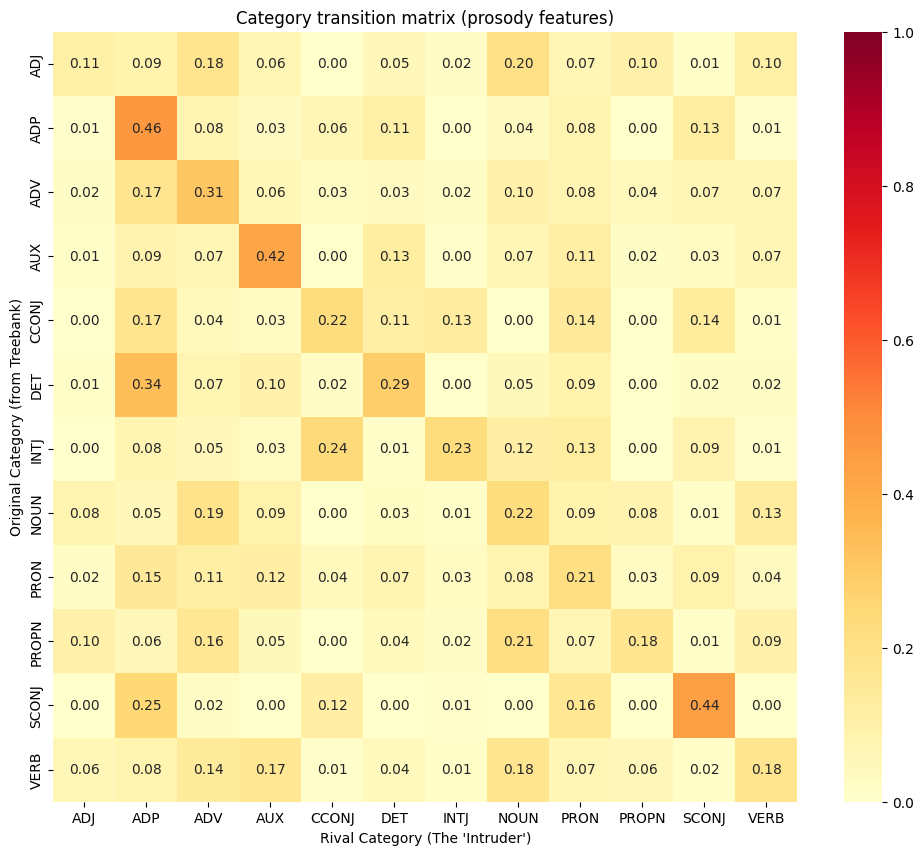

In [20]:
stability_matrix = build_transition_matrix(similarities_matrix, idx2lexunit, category_freqs)
plot_transition_matrix(stability_matrix, "Category transition matrix (prosody features)", drop_categories=('X', 'SYM'))

In [21]:
def get_pulling_features_by_mass(
    lex_unit, rival_category,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Features that actually build the unit↔rival cosine similarity.
 
    Restrict to the active space, L2-normalise the unit (û) and each rival
    neighbour, average the normalised rivals into a direction r̂, then rank
    features by ûᵢ · r̂ᵢ. These contributions sum to the mean cosine similarity
    between the unit and its rival-category neighbours, so `share` tells you how
    much of the overlap each feature is responsible for.
    """
    unit_idx = lexunit2idx[lex_unit]
 
    cols = np.where(feature_mask)[0] if feature_mask is not None \
        else np.arange(feature_matrix.shape[1])
 
    u = feature_matrix[unit_idx, cols].astype(float)
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return []
    u_hat = u / u_norm
 
    candidate_idx = np.where(similarity_matrix[unit_idx] >= sim_threshold)[0]
    neighbour_indices = sorted(
        [i for i in candidate_idx if i != unit_idx],
        key=lambda i: similarity_matrix[unit_idx][i], reverse=True,
    )[:max_neighbours]
    rival_neighbour_indices = [
        i for i in neighbour_indices if idx2lexunit[i][1] == rival_category
    ]
    if not rival_neighbour_indices:
        print(f"No neighbours of category '{rival_category}' found for {lex_unit}.")
        return []
 
    rival_block = feature_matrix[np.ix_(rival_neighbour_indices, cols)].astype(float)
    rn = np.linalg.norm(rival_block, axis=1, keepdims=True)
    rn[rn == 0] = 1.0
    rival_hat = (rival_block / rn).mean(axis=0)
 
    contribution = u_hat * rival_hat          # sums to mean cosine similarity
    total = contribution.sum()
 
    order = np.argsort(contribution)[::-1][:top_k_features]
    rows = []
    for local_i in order:
        c = contribution[local_i]
        if c <= 0:
            continue
        g_idx = int(cols[local_i])
        rows.append({
            "feature":      idx2feature[g_idx],
            "unit_value":   float(u[local_i]),
            "rival_dir":    float(rival_hat[local_i]),
            "contribution": float(c),
            "share":        float(c / total) if total > 0 else 0.0,
        })
    return rows

In [22]:
LEX_UNIT  = ('dois', 'VERB')
RIVAL_CAT = "AUX"
 
results = get_pulling_features_by_mass(
    LEX_UNIT, RIVAL_CAT,
    feature_matrix, similarities_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    top_k_features=20,
)
 
print(f"Top features building the {LEX_UNIT} → {RIVAL_CAT} similarity ")
print(f"{'Feature':<48} {'unit':>6}  {'r_dir':>6}  {'contrib':>8}  {'share':>6}")
print("-" * 82)
for r in results:
    print(f"{r['feature']:<48} {r['unit_value']:>6.3f}  {r['rival_dir']:>6.3f}  "
          f"{r['contribution']:>8.4f}  {r['share']:>5.1%}")

Top features building the ('dois', 'VERB') → AUX similarity 
Feature                                            unit   r_dir   contrib   share
----------------------------------------------------------------------------------
node:X:own:Package=In                             1.000   0.144    0.0206   2.9%
node:X:prevSyl:AvgHeightGlo=M                     1.000   0.130    0.0186   2.6%
node:X:prevSyl:PitchRangeGlo=L                    1.000   0.125    0.0179   2.5%
node:X:childSyl1:PitchRangeGlo=L                  0.667   0.146    0.0140   2.0%
node:X:childSyl1:AvgHeightGlo=M                   0.667   0.144    0.0137   1.9%
node:X:prev:Package=In                            1.000   0.095    0.0136   1.9%
node:X:childSyl1:SlopeGlo=Flat                    0.667   0.133    0.0127   1.8%
node:X:next:RhythmGroup=Strong                    1.000   0.087    0.0124   1.7%
node:X:prev:Group=In                              1.000   0.079    0.0113   1.6%
node:X:prev:Foot=In                          

In [23]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Words from `original_cat` most pulled toward `rival_cat`."""
    matches = [
        {"word": word, "purity": float(d["purity"]), "entropy": float(d["entropy"])}
        for (word, o_cat), d in scores_dict.items()
        if o_cat == original_cat and d["rival_category"] == rival_cat
    ]
    # Lowest combined score first — least pure, highest entropy.
    # matches.sort(key=lambda x: 0.7 * x["purity"] - 0.3 * x["entropy"])
    matches.sort(key=lambda x: x["purity"])
    return [(m["word"], f'{m["purity"]:.2f}', f'{m["entropy"]:.2f}')
            for m in matches[:top_n]]

def get_aggregate_pulling_features_by_mass(
    scores_dict, original_cat, rival_cat,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_words=10, top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat,
                                        top_n=top_k_words)
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None
 
    print(f"Analyzing {len(bridge_words)} bridge words: "
          f"{[w[0] for w in bridge_words]}\\n")
 
    per_feature = {}
    for word, _p, _e in bridge_words:
        lex_unit = (word, original_cat)
        if lex_unit not in lexunit2idx:
            continue
        feats = get_pulling_features_by_mass(
            lex_unit=lex_unit, rival_category=rival_cat,
            feature_matrix=feature_matrix, similarity_matrix=similarity_matrix,
            idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
            idx2feature=idx2feature, feature2idx=feature2idx,
            feature_mask=feature_mask,
            top_k_features=top_k_features * 3,
            sim_threshold=sim_threshold, max_neighbours=max_neighbours,
        )
        for fd in feats:
            d = per_feature.setdefault(
                fd["feature"],
                {"contribs": [], "unit_values": []},
            )
            d["contribs"].append(fd["contribution"])
            d["unit_values"].append(fd["unit_value"])
 
    if not per_feature:
        print("No features collected — check bridge words and similarity threshold.")
        return None
 
    rows = [{
        "feature":        fname,
        "count_words":    len(d["contribs"]),
        "total_contrib":  float(np.sum(d["contribs"])),
        "avg_contrib":    float(np.mean(d["contribs"])),
        "avg_unit_value": float(np.mean(d["unit_values"])),
    } for fname, d in per_feature.items()]
    rows.sort(key=lambda r: r["total_contrib"], reverse=True)
    return pd.DataFrame(rows[:top_k_features])

In [25]:
ORIGINAL_CAT = "ADJ"
RIVAL_CAT    = "NOUN"
 
df_mass = get_aggregate_pulling_features_by_mass(
    scores_dict=scores,
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities_matrix,
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    top_k_words=40, top_k_features=25,
)
 
if df_mass is not None:
    print(df_mass.to_string(index=False))

Analyzing 40 bridge words: ['Haut', 'abominable', 'accueillant', 'africaines', 'amical', 'autrichien', 'bourgeoise', 'bénéfique', 'chrétiens', 'civiles', 'commun', 'complexes', 'cumulatif', 'différent', 'direct', 'forts', 'haute', 'historiques', 'honteux', 'lumineuse', 'meilleures', 'médiane', 'médico-sociales', 'nouvel', 'onéreux', 'orthodoxe', 'pareilles', 'plein', 'relatif', 'sincère', 'spécialisé', 'stratifiée', 'vain', 'vide', 'étonnée', 'doué', 'libre', 'actuelle', 'élégante', 'concrets']\n
                          feature  count_words  total_contrib  avg_contrib  avg_unit_value
 node:X:childSyl1:PitchRangeGlo=L           33       0.410830     0.012449        0.969697
    node:X:prevSyl:AvgHeightGlo=M           30       0.380385     0.012680        0.950000
   node:X:prevSyl:PitchRangeGlo=L           30       0.377972     0.012599        0.966667
node:X:own:ProminenceFinal=Strong           30       0.354994     0.011833        0.950000
    node:X:own:RhythmGroup=Strong          

In [26]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SLOT_RE = re.compile(r"^node:X:([^:]+):")
def bridge_table(scores, original_cat, rival_cat):
    """All candidates, with the quantities that actually define a bridge."""
    rows = []
    for (word, cat), d in scores.items():
        if cat != original_cat or d["rival_category"] != rival_cat:
            continue
        p, r = float(d["purity"]), float(d["rival_weight_ratio"])
        rows.append({"word": word, "purity": p, "rival_share": r,
                     "entropy": float(d["entropy"]),
                     "concentration": p + r,     # mass in just these two categories
                     "bridge_score": r - p})     # >0 = more rival-like than own-like
    return pd.DataFrame(rows).sort_values("bridge_score", ascending=False)

In [27]:
def select_bridge_words(scores, original_cat, rival_cat,
                        min_bridge_score=0.0, min_concentration=0.7, max_n=None):
    t = bridge_table(scores, original_cat, rival_cat)
    t = t[(t["bridge_score"] >= min_bridge_score) &
          (t["concentration"] >= min_concentration)]
    if max_n:
        t = t.head(max_n)
    return t["word"].tolist()

In [30]:
bridge_words = set(select_bridge_words(scores, ORIGINAL_CAT, RIVAL_CAT,))
#to get the number of occurrences so we know how representative the results are
occ_all = {w:n_occ[lexunit2idx[(w, ORIGINAL_CAT)]] for (w,c) in idx2lexunit.values() if c == ORIGINAL_CAT}
nb_occ_bridge = np.array([v for w,v in occ_all.items() if w in bridge_words])
nb_occ_non_bridge = np.array([v for w,v in occ_all.items() if w not in bridge_words])
print(f"bridge {ORIGINAL_CAT}: median {np.median(nb_occ_bridge):.0f} occ, "
          f"{np.mean(nb_occ_bridge <= 3):.0%} occur 3x or fewer (n={len(nb_occ_bridge)})")
print(f"other  {ORIGINAL_CAT}: median {np.median(nb_occ_non_bridge):.0f} occ, "
          f"{np.mean(nb_occ_non_bridge <= 3):.0%} occur 3x or fewer (n={len(nb_occ_non_bridge)})")


bridge ADJ: median 1 occ, 100% occur 3x or fewer (n=40)
other  ADJ: median 1 occ, 85% occur 3x or fewer (n=599)


In [35]:
bridge_ids = np.array([lexunit2idx[(w, ORIGINAL_CAT)] for w in bridge_words], dtype=int)
orig_ids = np.array([i for i, lu in idx2lexunit.items() if lu[1] == ORIGINAL_CAT and i not in bridge_ids], dtype=int)
rival_ids = np.array([i for i, lu in idx2lexunit.items() if lu[1] == RIVAL_CAT], dtype=int)

p_orig, p_bridge, p_rival = feature_matrix[orig_ids].mean(axis=0), feature_matrix[bridge_ids].mean(axis=0), feature_matrix[rival_ids].mean(axis=0)

rows = []
for j, f in idx2feature.items():
    if "=" not in f:
        continue
    var, value = f.rsplit("=", 1)
    slot = SLOT_RE.match(f).group(1)
    rows.append({"variable": var.replace("node:X:", ""), "value": value,
                    "slot": slot, "tier": "syllable" if "Syl" in slot else "token",
                    "p_orig": p_orig[j], "p_bridge": p_bridge[j], "p_rival": p_rival[j]})

df = pd.DataFrame(rows)
df["gap_rival_orig"] = df["p_rival"] - df["p_orig"]
df["position"] = np.where(np.abs(df["gap_rival_orig"]) > 1e-9, (df["p_bridge"] - df["p_orig"]) / df["gap_rival_orig"], np.nan) 
df.attrs["cats"] = (ORIGINAL_CAT, RIVAL_CAT)
df.attrs["n"] = dict(zip(["orig", "bridge", "rival"], [len(orig_ids), len(bridge_ids), len(rival_ids)]))
df.attrs["bridge_words"] = bridge_words

In [39]:
def pick_axes(df, tier=None, n_axes=8, min_gap=0.08):
    """One axis per variable: the value that best separates the two categories"""
    d = df if tier is None else df[df["tier"] == tier]
    d = d[abs(d["gap_rival_orig"]) > min_gap]
    best = (d.sort_values("gap_rival_orig", ascending=False)
              .drop_duplicates("variable")
              .head(n_axes).copy())
    best["label"] = best["variable"] + " = " + best["value"]
    return best.sort_values("gap_rival_orig", ascending=False).reset_index(drop=True)

def axes_from_labels(df, labels):
    """Build the axis frame from an explicit list of 'variable = value' strings,
    in the order given. Bypasses the automatic gap-based selection."""
    d = df.copy()
    d["label"] = d["variable"] + " = " + d["value"]
    missing = [l for l in labels if l not in set(d["label"])]
    if missing:
        raise ValueError(f"not found in df: {missing}")
    return (d[d["label"].isin(labels)]
              .set_index("label").loc[labels].reset_index())


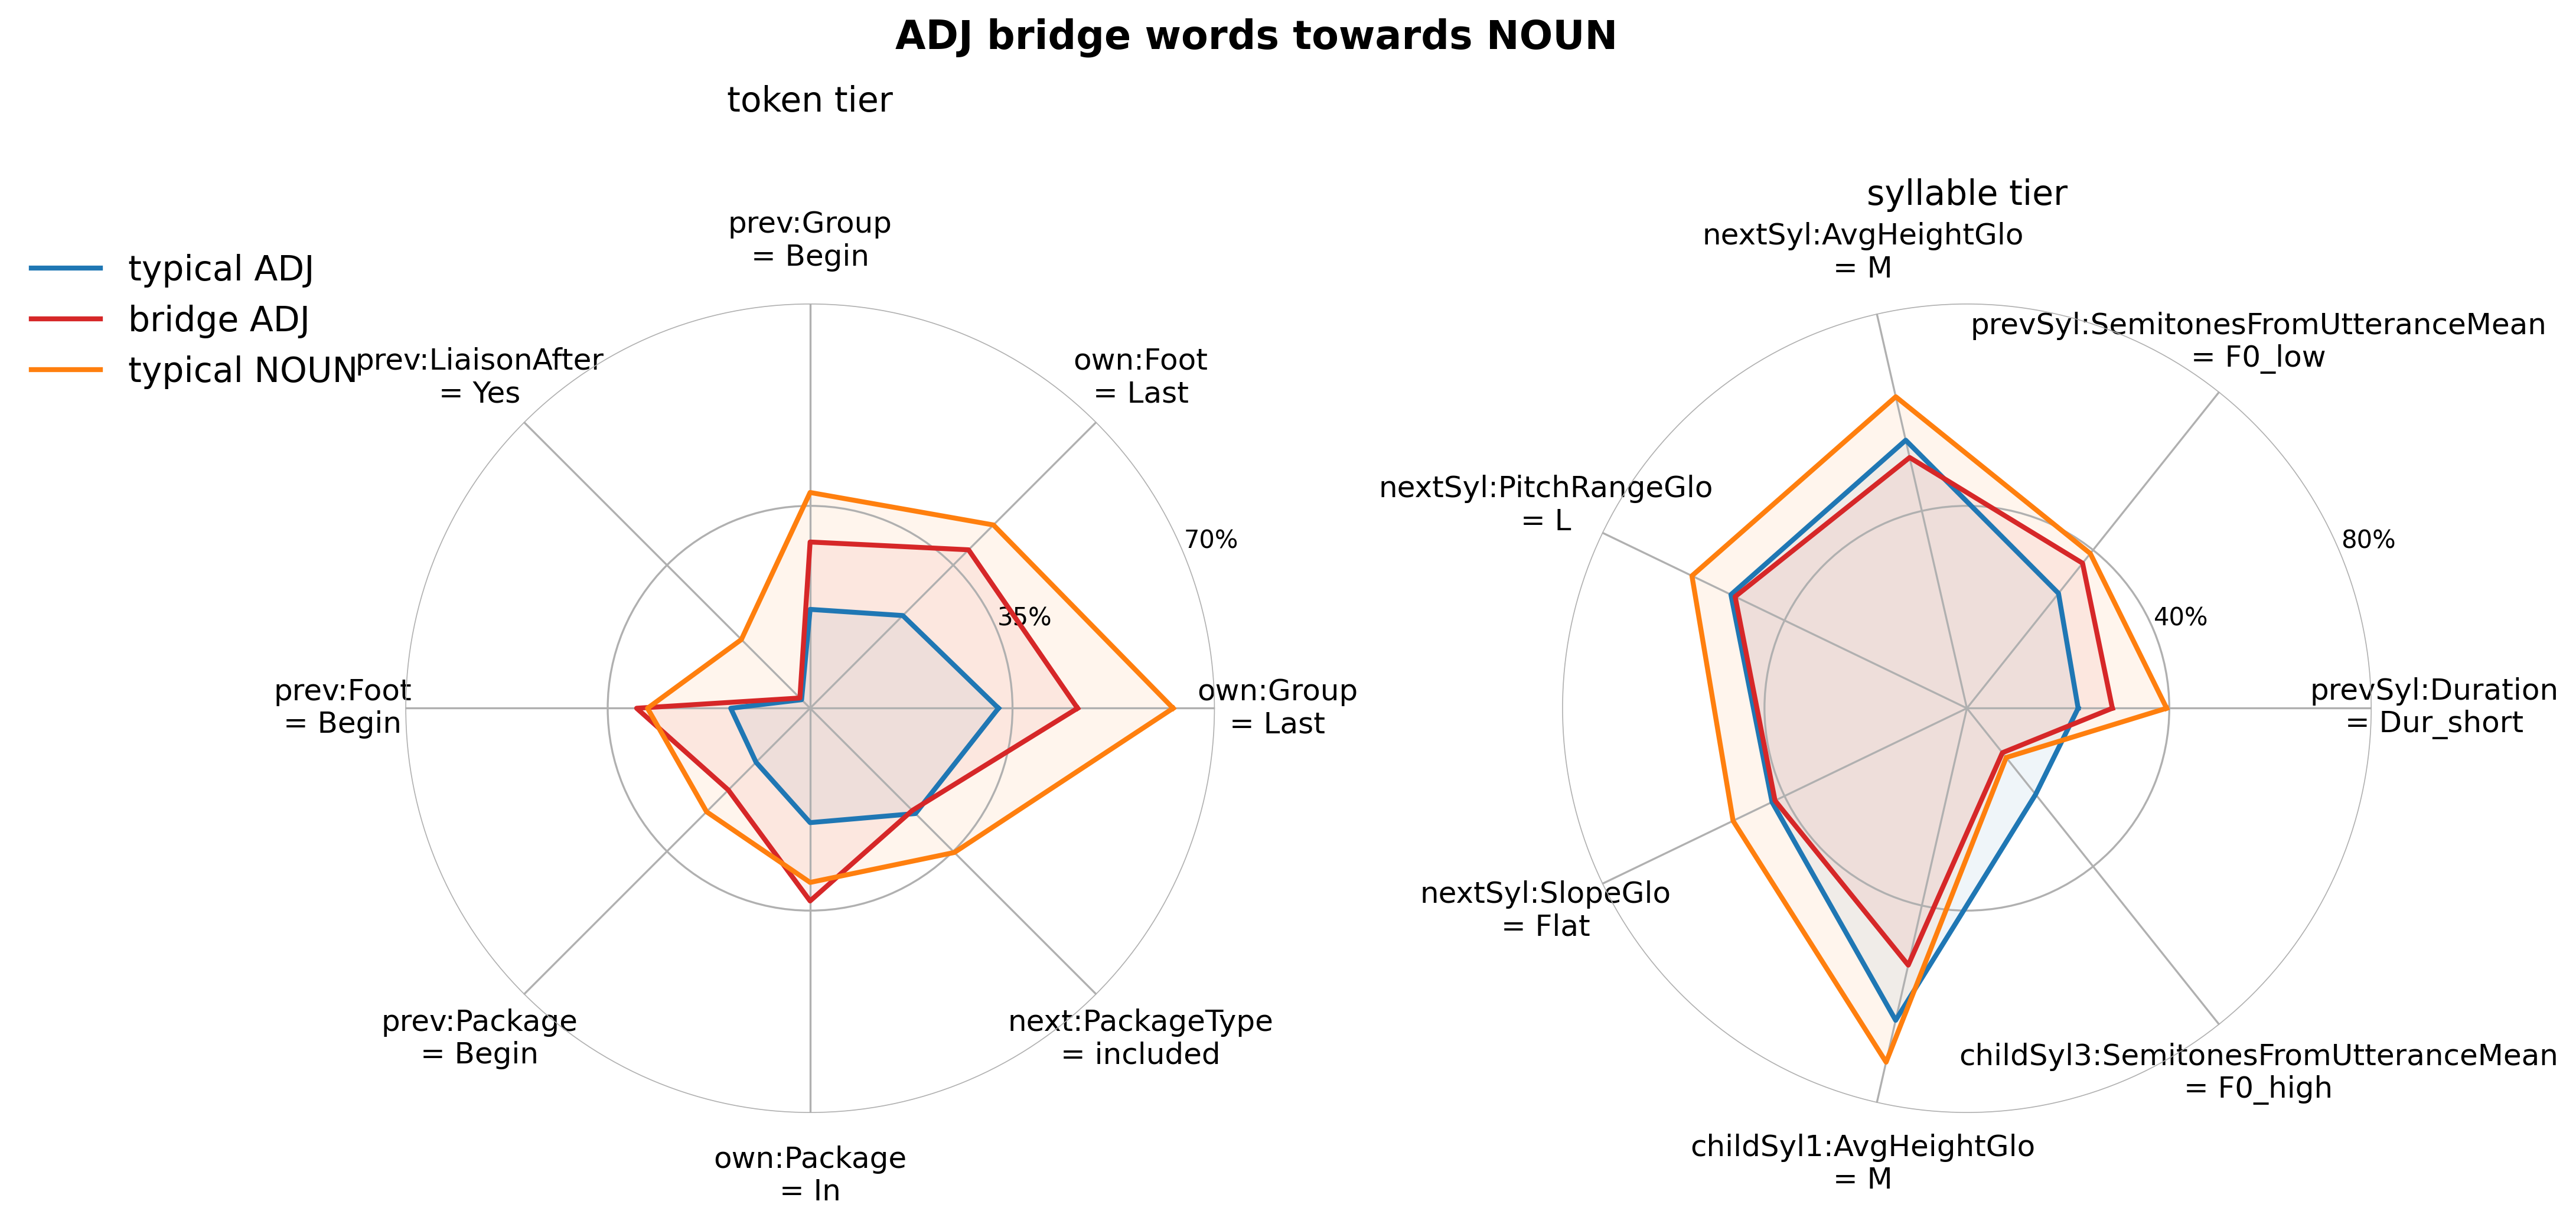

In [41]:
def plot_radars(df, n_axes=8, min_gap=0.08, manual=None):
    o, r = df.attrs["cats"]
    series = [(f"typical {o}", "p_orig", "tab:blue"),
              (f"bridge {o}", "p_bridge", "tab:red"),
              (f"typical {r}", "p_rival", "tab:orange")]
    
    if manual:
        tiers = list(manual)
    else:
        tiers = [t for t in ["token", "syllable"]
                 if len(pick_axes(df, t, n_axes, min_gap)) >= 3]
                 
    fig, axs = plt.subplots(1, len(tiers), figsize=(7.5 * len(tiers), 7),
                            subplot_kw=dict(polar=True), dpi=300)
    axs = np.atleast_1d(axs)
    
    for ax, tier in zip(axs, tiers):
        a = axes_from_labels(df, manual[tier]) if manual \
            else pick_axes(df, tier, n_axes, min_gap)
        
        ang = np.linspace(0, 2 * np.pi, len(a), endpoint=False).tolist()
        ang += ang[:1]
        
        for name, col, c in series:
            v = a[col].tolist()
            v += v[:1]
            ax.plot(ang, v, color=c, linewidth=2, label=name)
            ax.fill(ang, v, color=c, alpha=0.07)
            
        top = float(np.ceil(a[["p_orig", "p_bridge", "p_rival"]].values.max() * 10) / 10)
        ax.set_ylim(0, top)
        
        ticks = np.linspace(0, top, 3)[1:]
        ax.set_yticks(ticks)
        
        # INCREASED FONT SIZE for the inner circle numbers (from 7 to 10)
        ax.set_yticklabels([f"{t:.0%}" for t in ticks], fontsize=10)
        
        formatted_labels = [label.replace(" = ", "\n= ") for label in a["label"]]
        
        ax.set_xticks(ang[:-1])
        ax.set_xticklabels(formatted_labels, fontsize=12, ha="center")
        
        ax.tick_params(axis='x', pad=15)
        ax.spines['polar'].set_visible(False)
        
        # INCREASED PAD to push the subtitle away from the plot (from 26 to 40)
        ax.set_title(f"{tier} tier", pad=40, fontsize=14)
        
    axs[0].legend(loc="upper left", bbox_to_anchor=(-0.5, 1.1), frameon=False, fontsize=14)
    
    fig.suptitle(f"{o} bridge words towards {r}", fontsize=16, fontweight="bold")
    
    # ADJUSTED RECT to bring the main title slightly down and frame everything nicely
    fig.tight_layout(rect=[0, 0, 1, 1])
    
    plt.show()

plot_radars(df, n_axes=8, min_gap=0.08, manual=None)